# TP Bonus

In [1]:
import random
import re
from typing import Literal
import warnings
from itertools import chain
from collections import Counter
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Flatten,
    Dropout,
    GlobalAveragePooling1D,
    Conv1D,
    LSTM,
    Bidirectional,
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
PALETTE = sns.color_palette("colorblind")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()


def ensure_stopwords_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


ensure_stopwords_downloaded()

STOP_WORDS = set(stopwords.words("french"))
NLP = spacy.load("fr_core_news_md")

## Partie 1 — Extraction et Nettoyage des Données

### 1.1 Chargement et exploration

In [2]:
offres = [
    "Nous recherchons un développeur Python expérimenté pour rejoindre notre équipe. CDI, télétravail partiel, salaire selon profil.",
    "Poste de Data Scientist à pourvoir immédiatement. Maîtrise de scikit-learn et SQL indispensable. Bac+5 requis.",
    "Offre d'emploi : Chef de projet digital, 5 ans d'expérience minimum, secteur e-commerce, Paris 75008.",
    "Recrutement urgent : technicien réseau, habilitation sécurité souhaitée, contrat 12 mois renouvelable.",
    "Rejoignez notre cabinet comptable : poste de comptable senior, maîtrise de Sage, déplacements occasionnels.",
    "Nous recrutons un ingénieur DevOps. Expérience Kubernetes et CI/CD requise. Startup en forte croissance.",
    "Offre : Responsable RH, gestion de 200 collaborateurs, connaissance du droit social impérative.",
    "Recherche commercial terrain BtoB, véhicule de fonction fourni, variable attractif, secteur PACA.",
    "CDI à pourvoir : UX Designer, maîtrise de Figma, portfolio exigé, environnement agile.",
    "Poste ouvert : analyste financier junior, formation assurée, diplôme grande école apprécié.",
]

cvs = [
    "Ingénieur logiciel avec 7 ans d'expérience en Python et Java. Diplômé de l'INSA Lyon. Passionné par l'IA.",
    "Data Analyst junior, maîtrise de Power BI et Excel avancé. À la recherche d'une opportunité en CDI sur Paris.",
    "Profil polyvalent : marketing digital, gestion de communauté, création de contenu. 3 ans d'expérience.",
    "Développeur fullstack React/Node.js, freelance depuis 2 ans, disponible pour mission longue durée.",
    "Comptable confirmé, 10 ans en cabinet d'expertise, maîtrise de Cegid et des normes IFRS.",
    "Chargée de communication, bilingue anglais-espagnol, expérience ONG et secteur privé.",
    "Technicien informatique, certifié CISCO CCNA, disponible immédiatement, mobilité nationale.",
    "Chef de projet IT, certifié PMP, expérience en transformation digitale dans le secteur bancaire.",
    "Juriste d'entreprise, spécialité droit des contrats et propriété intellectuelle, 5 ans en startup.",
    "Graphiste freelance, maîtrise Adobe Suite, portfolio disponible sur demande, ouvert au CDI.",
]

In [3]:
data = []
for _ in range(10):
    for texte in offres:
        data.append(
            {"texte": texte + f" (réf. {random.randint(1000, 9999)})", "label": "offre"}
        )
    for texte in cvs:
        data.append(
            {"texte": texte + f" (id {random.randint(1000, 9999)})", "label": "cv"}
        )

df = pd.DataFrame(data).sample(frac=1, random_state=42).reset_index(drop=True)
print(df["label"].value_counts())
df.to_csv("corpus_emploi.csv", index=False)

label
cv       100
offre    100
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   texte   200 non-null    object
 1   label   200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


Le dataset contient 200 textes.

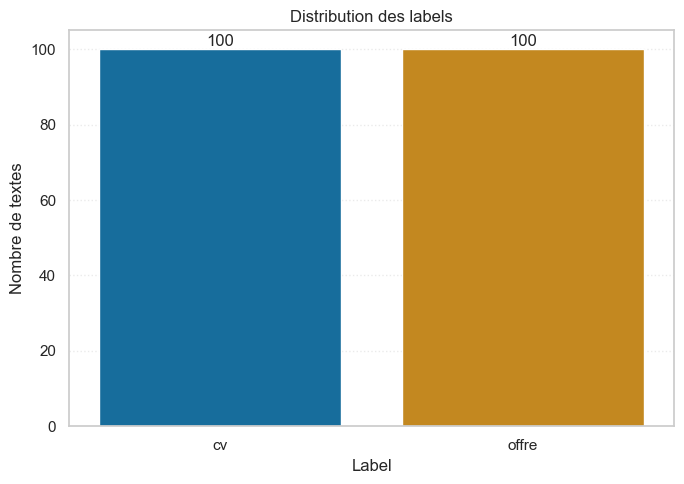

In [5]:
plt.figure(figsize=(7, 5))

labels = df["label"].value_counts()

barplot = sns.barplot(
    x=labels.index,
    y=labels.values,
    palette=PALETTE[:2],
    hue=labels.index,
    legend=False,
)

for container in barplot.containers:
    barplot.bar_label(container)

plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.title("Distribution des labels")
plt.xlabel("Label")
plt.ylabel("Nombre de textes")

plt.tight_layout()
plt.show()

Distribution équilibrée des labels.

### 1.2 Nettoyage du texte

In [6]:
class InvalidMethodError(ValueError):
    """Raised when an unsupported method is provided."""

    pass


def clean_text(text: str, method: Literal["NLTK", "SPACY"] = "SPACY") -> str:
    if text is None:
        return ""

    if method not in {"NLTK", "SPACY"}:
        raise InvalidMethodError(
            f"`method` must be one of ['NLTK', 'SPACY'], got '{method}'"
        )

    try:
        text = str(text)
        # 1. Conversion en minuscules
        text = text.lower()
        # 2. Suppression des chiffres et des références entre parenthèses
        text = re.sub(r"\(.*?\)", " ", text)
        text = re.sub(r"\d+", " ", text)
        # 3. Suppression de la ponctuation
        text = re.sub(r"[^\w\s]", " ", text)
        # 4. Suppression des stopwords français
        # 5. Lemmatisation
        match method:
            case "NLTK":
                tokens = word_tokenize(text, language="french")
                tokens = [
                    word for word in tokens if word not in STOP_WORDS and len(word) > 1
                ]
                lemmatizer = WordNetLemmatizer()
                tokens = [lemmatizer.lemmatize(word) for word in tokens]
            case "SPACY":
                doc = NLP(text)
                tokens = [
                    token.lemma_
                    for token in doc
                    if not token.is_stop and not token.is_space and len(token.text) > 1
                ]
                return tokens
        return tokens
    except Exception as exception:
        raise RuntimeError(
            f"Unexpected error during text cleaning: {exception}"
        ) from exception


df["tokens"] = df["texte"].apply(clean_text)
df["texte_nettoye"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

### 1.3 Analyse exploratoire

In [7]:
df["nombre_mots"] = df["tokens"].apply(lambda l: len(l) if isinstance(l, list) else 0)

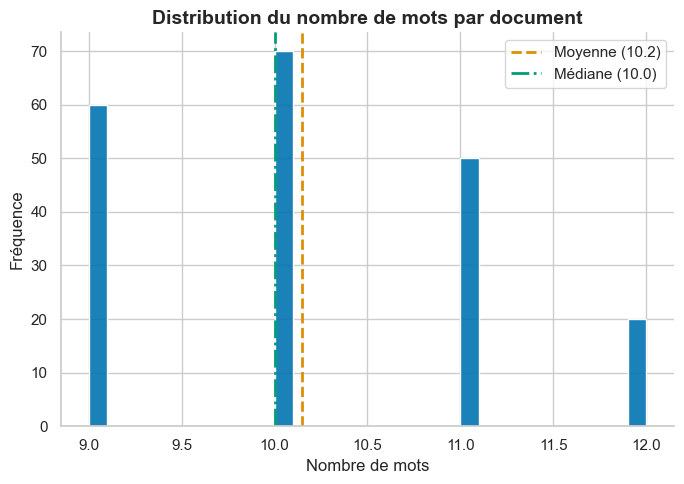

In [8]:
plt.figure(figsize=(7, 5))

ax = sns.histplot(
    data=df,
    x="nombre_mots",
    bins=30,
    kde=False,
    color=PALETTE[0],
    edgecolor="white",
    alpha=0.9,
)

ax.set_title("Distribution du nombre de mots par document", fontsize=14, weight="bold")
ax.set_xlabel("Nombre de mots", fontsize=12)
ax.set_ylabel("Fréquence", fontsize=12)

mean_val = df["nombre_mots"].mean()
median_val = df["nombre_mots"].median()

plt.axvline(
    mean_val,
    color=PALETTE[1],
    linestyle="--",
    linewidth=2,
    label=f"Moyenne ({mean_val:.1f})",
)

plt.axvline(
    median_val,
    color=PALETTE[2],
    linestyle="-.",
    linewidth=2,
    label=f"Médiane ({median_val:.1f})",
)

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

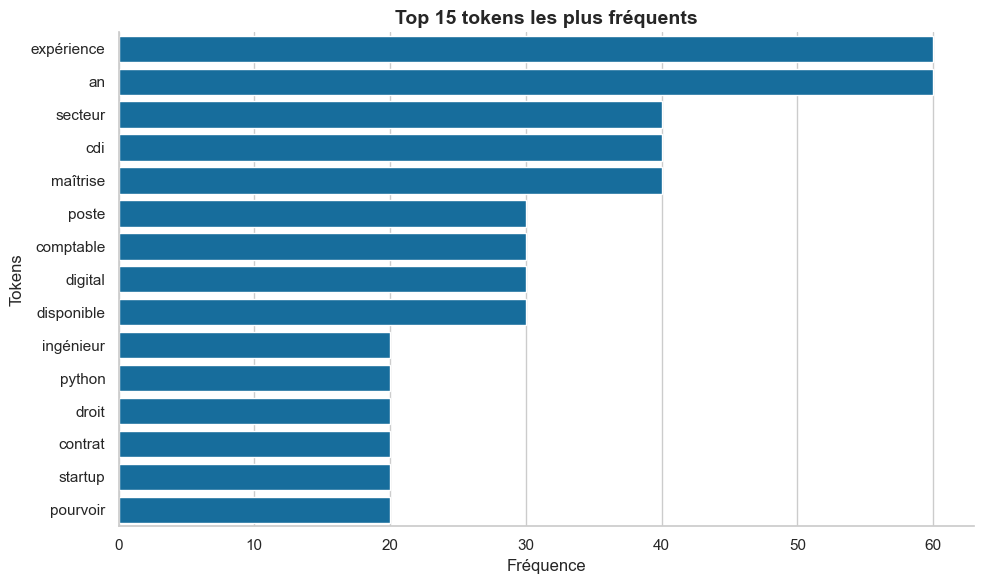

In [9]:
counter = Counter(list(chain.from_iterable(df["tokens"])))

top_n = 15
most_common = counter.most_common(top_n)
tokens, counts = zip(*most_common)

plt.figure(figsize=(10, 6))

sns.barplot(x=list(counts), y=list(tokens), color=PALETTE[0])

plt.title(f"Top {top_n} tokens les plus fréquents", weight="bold", fontsize=14)
plt.xlabel("Fréquence")
plt.ylabel("Tokens")

sns.despine()
plt.tight_layout()
plt.show()

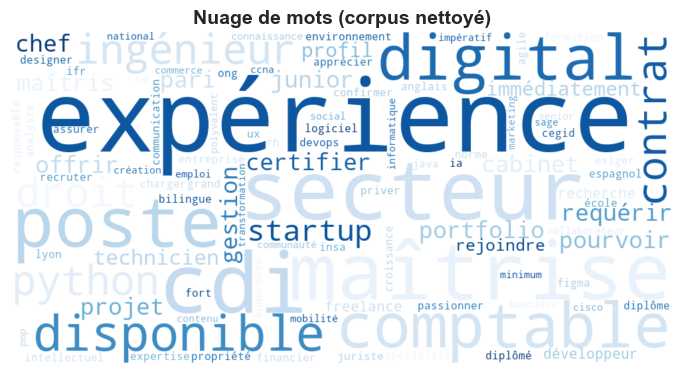

In [10]:
all_text = df["texte_nettoye"].dropna().astype(str).str.cat(sep=" ")

plt.figure(figsize=(7, 5))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Blues",
    max_words=100,
    collocations=False,
).generate(all_text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Nuage de mots (corpus nettoyé)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Partie 2 — Vectorisation des Textes avec TensorFlow

### 2.1 Préparation du tokenizer

In [11]:
X = df["texte_nettoye"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

In [12]:
# Tokenisation
max_words = 5000  # Taille du vocabulaire
max_len = 50  # Longueur maximale des séquences

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Conversion en séquences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post",
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post",
)

### 2.2 Encodage des labels

In [13]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.fit_transform(y_test)

y_train_onehot = keras.utils.to_categorical(y_train_encoded, num_classes=2)
y_test_onehot = keras.utils.to_categorical(y_test_encoded, num_classes=2)

## Partie 3 — Entraînement de Réseaux de Neurones avec TensorFlow

### 3.1 Modèle Dense Simple

In [14]:
embedding_dim = 128


def create_model_dense(
    max_words: int, embedding_dim: int, max_len: int
) -> keras.Sequential:
    model_dense = keras.Sequential(
        [
            Embedding(max_words, embedding_dim, input_length=max_len, name="embedding"),
            Flatten(),
            Dense(128, activation="relu", name="hidden1"),
            Dropout(0.3, name="drop1"),
            Dense(64, activation="relu", name="hidden2"),
            Dropout(0.2, name="drop2"),
            Dense(32, activation="relu", name="hidden3"),
            Dropout(0.1, name="drop3"),
            Dense(2, activation="sigmoid", name="output"),
        ]
    )

    model_dense.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model_dense


model_dense = create_model_dense(max_words, embedding_dim, max_len)

In [15]:
def create_early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr():
    return keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


t0_model_dense = time.time()
history_model_dense = model_dense.fit(
    X_train_pad,
    y_train_onehot,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)
t1_model_dense = time.time()

fitting_time = []
fitting_time.append(t1_model_dense - t0_model_dense)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.4732 - loss: 0.6944 - val_accuracy: 0.4643 - val_loss: 0.6898 - learning_rate: 0.0010
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5714 - loss: 0.6897 - val_accuracy: 0.3929 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5982 - loss: 0.6748 - val_accuracy: 0.3929 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7054 - loss: 0.6474 - val_accuracy: 0.4643 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7589 - loss: 0.6221 - val_accuracy: 0.8929 - val_loss: 0.5915 - learning_rate: 0.0010
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8036 - loss: 0.5872 - val_accuracy: 1.0000 - val_loss: 0.5120 - learning_rate: 0.0010
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9286 - loss: 0.5125 - val_accuracy: 1.0000

### 3.2 Modèle avec GlobalAveragePooling1D

In [16]:
def create_model_gap(
    max_words: int, embedding_dim: int, max_len: int
) -> keras.Sequential:
    model_gap = keras.Sequential(
        [
            Embedding(max_words, embedding_dim, input_length=max_len, name="embedding"),
            GlobalAveragePooling1D(),
            Dense(128, activation="relu", name="hidden1"),
            Dropout(0.3, name="drop1"),
            Dense(64, activation="relu", name="hidden2"),
            Dropout(0.2, name="drop2"),
            Dense(32, activation="relu", name="hidden3"),
            Dropout(0.1, name="drop3"),
            Dense(2, activation="sigmoid", name="output"),
        ]
    )

    model_gap.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model_gap


model_gap = create_model_gap(max_words, embedding_dim, max_len)

t0_model_gap = time.time()
history_model_gap = model_gap.fit(
    X_train_pad,
    y_train_onehot,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)
t1_model_gap = time.time()

fitting_time.append(t1_model_gap - t0_model_gap)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.4464 - loss: 0.6940 - val_accuracy: 0.3929 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5089 - loss: 0.6931 - val_accuracy: 0.3929 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5536 - loss: 0.6923 - val_accuracy: 0.3929 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 4/10
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5625 - loss: 0.6903
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5357 - loss: 0.6914 - val_accuracy: 0.3929 - val_loss: 0.6964 - learning_rate: 0.0010
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5536 - loss: 0.6895 - val_accuracy: 0.3929 - val_loss: 0.6974 - learning_rate: 5.0000e-04
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5536 - loss: 0.6891 - val_accuracy: 0.3

### 3.3 Modèle CNN (Convolutional Neural Network)

In [17]:
def create_model_cnn(
    max_words: int, embedding_dim: int, max_len: int
) -> keras.Sequential:
    model_cnn = keras.Sequential(
        [
            Embedding(max_words, embedding_dim, input_length=max_len, name="embedding"),
            Conv1D(128, 5, activation="relu", name="cnn"),
            GlobalAveragePooling1D(),
            Dense(128, activation="relu", name="hidden1"),
            Dropout(0.3, name="drop1"),
            Dense(64, activation="relu", name="hidden2"),
            Dropout(0.2, name="drop2"),
            Dense(32, activation="relu", name="hidden3"),
            Dropout(0.1, name="drop3"),
            Dense(2, activation="sigmoid", name="output"),
        ]
    )

    model_cnn.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model_cnn


model_cnn = create_model_cnn(max_words, embedding_dim, max_len)

t0_model_cnn = time.time()
history_model_cnn = model_cnn.fit(
    X_train_pad,
    y_train_onehot,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)
t1_model_cnn = time.time()

fitting_time.append(t1_model_cnn - t0_model_cnn)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5625 - loss: 0.6912 - val_accuracy: 0.3929 - val_loss: 0.7025 - learning_rate: 0.0010
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5536 - loss: 0.6901 - val_accuracy: 0.3929 - val_loss: 0.7090 - learning_rate: 0.0010
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5536 - loss: 0.6884 - val_accuracy: 0.3929 - val_loss: 0.7124 - learning_rate: 0.0010
Epoch 4/10
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5938 - loss: 0.6798
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5536 - loss: 0.6877 - val_accuracy: 0.3929 - val_loss: 0.7140 - learning_rate: 0.0010
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5536 - loss: 0.6808 - val_accuracy: 0.3929 - val_loss: 0.7144 - learning_rate: 5.0000e-04
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5536 - loss: 0.6817 - val_accuracy: 0.3

### 3.4 Modèle LSTM (Recurrent Neural Network)

In [18]:
def create_model_lstm(
    max_words: int, embedding_dim: int, max_len: int
) -> keras.Sequential:
    model_lstm = keras.Sequential(
        [
            Embedding(max_words, embedding_dim, input_length=max_len, name="embedding"),
            LSTM(64, dropout=0.2, recurrent_dropout=0.2, name="lstm"),
            Dense(128, activation="relu", name="hidden1"),
            Dropout(0.3, name="drop1"),
            Dense(64, activation="relu", name="hidden2"),
            Dropout(0.2, name="drop2"),
            Dense(32, activation="relu", name="hidden3"),
            Dropout(0.1, name="drop3"),
            Dense(2, activation="sigmoid", name="output"),
        ]
    )

    model_lstm.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model_lstm


model_lstm = create_model_lstm(max_words, embedding_dim, max_len)

t0_model_lstm = time.time()
history_model_lstm = model_lstm.fit(
    X_train_pad,
    y_train_onehot,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)
t1_model_lstm = time.time()

fitting_time.append(t1_model_lstm - t0_model_lstm)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.5536 - loss: 0.6920 - val_accuracy: 0.3929 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5536 - loss: 0.6913 - val_accuracy: 0.3929 - val_loss: 0.7023 - learning_rate: 0.0010
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5536 - loss: 0.6921 - val_accuracy: 0.3929 - val_loss: 0.7051 - learning_rate: 0.0010
Epoch 4/10
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5938 - loss: 0.6817
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5536 - loss: 0.6871 - val_accuracy: 0.3929 - val_loss: 0.7083 - learning_rate: 0.0010
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5536 - loss: 0.6902 - val_accuracy: 0.3929 - val_loss: 0.7091 - learning_rate: 5.0000e-04
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5536 - loss: 0.6868 - val_accuracy: 0.3

### 3.5 Modèle Bidirectionnel LSTM

In [19]:
def create_model_bilstm(
    max_words: int, embedding_dim: int, max_len: int
) -> keras.Sequential:
    model_bilstm = keras.Sequential(
        [
            Embedding(max_words, embedding_dim, input_length=max_len, name="embedding"),
            Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
            Dense(128, activation="relu", name="hidden1"),
            Dropout(0.3, name="drop1"),
            Dense(64, activation="relu", name="hidden2"),
            Dropout(0.2, name="drop2"),
            Dense(32, activation="relu", name="hidden3"),
            Dropout(0.1, name="drop3"),
            Dense(2, activation="sigmoid", name="output"),
        ]
    )

    model_bilstm.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model_bilstm


model_bilstm = create_model_bilstm(max_words, embedding_dim, max_len)

t0_model_bilstm = time.time()
history_model_bilstm = model_bilstm.fit(
    X_train_pad,
    y_train_onehot,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)
t1_model_bilstm = time.time()

fitting_time.append(t1_model_bilstm - t0_model_bilstm)

Epoch 1/10


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 445ms/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.3929 - val_loss: 0.6943 - learning_rate: 0.0010
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5268 - loss: 0.6919 - val_accuracy: 0.3929 - val_loss: 0.6945 - learning_rate: 0.0010
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5714 - loss: 0.6887 - val_accuracy: 0.3929 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5804 - loss: 0.6858 - val_accuracy: 0.3929 - val_loss: 0.6892 - learning_rate: 0.0010
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5804 - loss: 0.6815 - val_accuracy: 0.3929 - val_loss: 0.6818 - learning_rate: 0.0010
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6161 - loss: 0.6712 - val_accuracy: 0.5714 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7054 - loss: 0.6566 - val_accuracy: 0.7857 - val_loss

## Partie 4 — Évaluation et Comparaison

### 4.1 Visualisation de l'entraînement

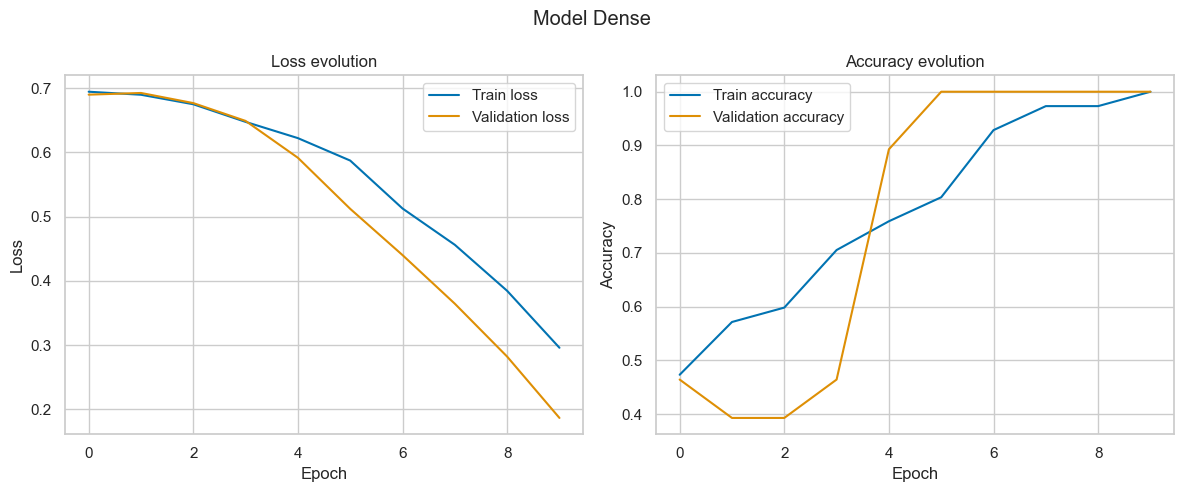

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Dense")

# Loss
ax1.plot(history_model_dense.history["loss"], label="Train loss")
ax1.plot(history_model_dense.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_model_dense.history["accuracy"], label="Train accuracy")
ax2.plot(history_model_dense.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

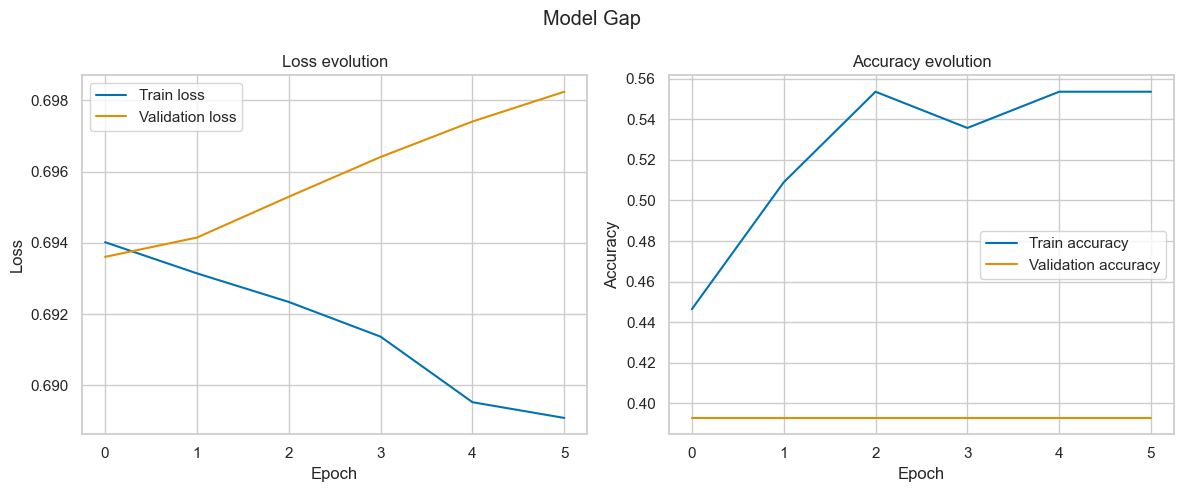

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Gap")

# Loss
ax1.plot(history_model_gap.history["loss"], label="Train loss")
ax1.plot(history_model_gap.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_model_gap.history["accuracy"], label="Train accuracy")
ax2.plot(history_model_gap.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

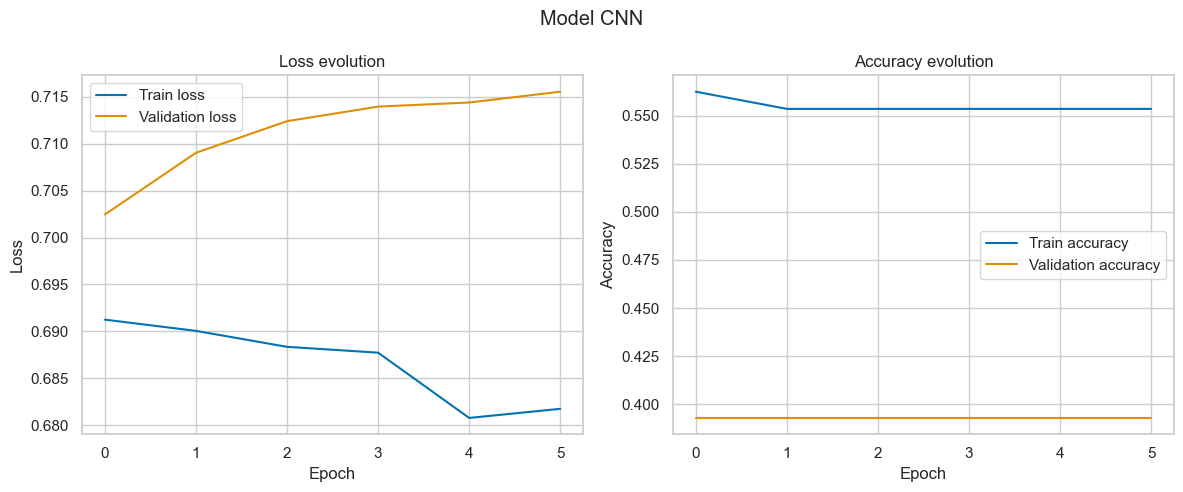

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model CNN")

# Loss
ax1.plot(history_model_cnn.history["loss"], label="Train loss")
ax1.plot(history_model_cnn.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_model_cnn.history["accuracy"], label="Train accuracy")
ax2.plot(history_model_cnn.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

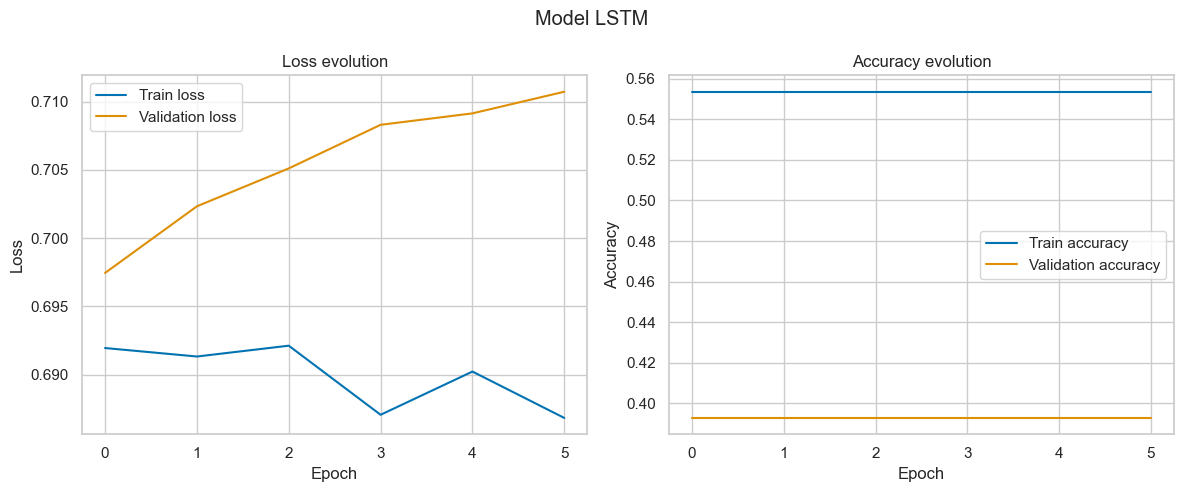

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model LSTM")

# Loss
ax1.plot(history_model_lstm.history["loss"], label="Train loss")
ax1.plot(history_model_lstm.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_model_lstm.history["accuracy"], label="Train accuracy")
ax2.plot(history_model_lstm.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

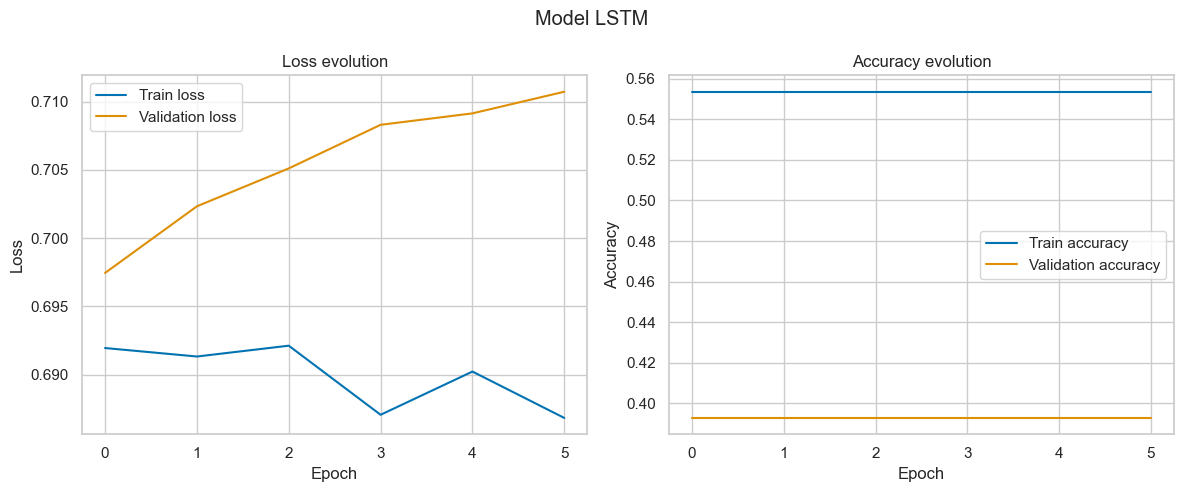

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model LSTM")

# Loss
ax1.plot(history_model_lstm.history["loss"], label="Train loss")
ax1.plot(history_model_lstm.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_model_lstm.history["accuracy"], label="Train accuracy")
ax2.plot(history_model_lstm.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

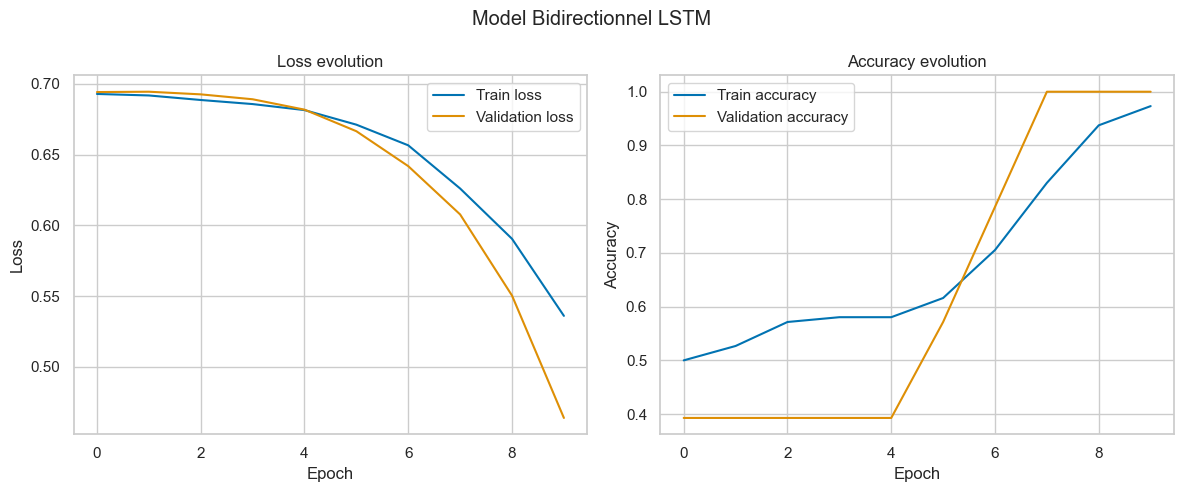

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Bidirectionnel LSTM")

# Loss
ax1.plot(history_model_bilstm.history["loss"], label="Train loss")
ax1.plot(history_model_bilstm.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_model_bilstm.history["accuracy"], label="Train accuracy")
ax2.plot(history_model_bilstm.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

### 4.2 Métriques de classification

In [26]:
models = {
    "dense": model_dense,
    "gap": model_gap,
    "cnn": model_cnn,
    "lstm": model_lstm,
    "bilstm": model_bilstm,
}

predictions = {}
for name, model in models.items():
    y_pred_vect = model.predict(X_test_pad)
    predictions[name] = np.argmax(y_pred_vect, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000027E29153BA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step


In [27]:
data = {
    "model": [],
    "accuracy": [],
    "F1_score_offre": [],
    "F1_score_cv": [],
    "AUC": [],
    "fitting_time": fitting_time,
}

for name, y_pred in predictions.items():
    data["model"].append(name)
    data["accuracy"].append(accuracy_score(np.argmax(y_test_onehot, axis=1), y_pred))
    f1_per_class = f1_score(np.argmax(y_test_onehot, axis=1), y_pred, average=None)
    data["F1_score_offre"].append(f1_per_class[0])
    data["F1_score_cv"].append(f1_per_class[1])
    data["AUC"].append(roc_auc_score(np.argmax(y_test_onehot, axis=1), y_pred))

metrics = pd.DataFrame(data)
metrics = metrics.set_index("model")
metrics

,accuracy,F1_score_offre,F1_score_cv,AUC,fitting_time
model,,,,,
dense,1.00,1.00000,1.0,1.0,1.864352
gap,0.45,0.62069,0.0,0.5,1.304355
cnn,0.45,0.62069,0.0,0.5,1.506919
lstm,0.45,0.62069,0.0,0.5,3.246939
bilstm,1.00,1.00000,1.0,1.0,4.926132


## Partie 5 : Prédiction sur de Nouveaux Textes

In [28]:
def predict_label(model, tokenizer, text, max_len, label_encoder):
    cleaned_tokens = clean_text(text)
    cleaned_text = " ".join(cleaned_tokens)

    seq = tokenizer.texts_to_sequences([cleaned_text])
    pad_seq = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    pred_vect = model.predict(pad_seq)
    pred_class = np.argmax(pred_vect, axis=1)[0]

    return label_encoder.inverse_transform([pred_class])[0]


new_offre = "Ingénieur en intelligence artificielle, expérience en TensorFlow et PyTorch souhaitée, projet R&D, CDI à Paris, salaire selon profil."
new_cv = "Ingénieur en IA avec 4 ans d'expérience en développement de modèles machine learning et deep learning. Diplômé de l'École Polytechnique. Passionné par la recherche appliquée et l'optimisation des algorithmes."
predicted_label1 = predict_label(
    model_bilstm, tokenizer, new_offre, max_len, label_encoder
)
print("Label prédit (Offre) :", predicted_label1)
predicted_label2 = predict_label(
    model_bilstm, tokenizer, new_cv, max_len, label_encoder
)
print("Label prédit (CV) :", predicted_label2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Label prédit (Offre) : cv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Label prédit (CV) : cv
